In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import matplotlib.pyplot as plt
import torchvision
import numpy as np

In [10]:
!pip freeze > requirements.txt

In [3]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

In [4]:
train_dataset = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.65MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.3MB/s]


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 10)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 84.5MB/s]


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [ ]:
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"✅ Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")


✅ Epoch [1/20], Loss: 0.1821


✅ Epoch [2/20], Loss: 0.1371


✅ Epoch [3/20], Loss: 0.1057


✅ Epoch [4/20], Loss: 0.0836


✅ Epoch [5/20], Loss: 0.0659


...

✅ Epoch [16/20], Loss: 0.0152


✅ Epoch [17/20], Loss: 0.0171


✅ Epoch [18/20], Loss: 0.0146


✅ Epoch [19/20], Loss: 0.0151


✅ Epoch [20/20], Loss: 0.0132


✅ Epoch [1/10] | Train Loss: 0.3596 | Val Loss: 0.1944 | Val Acc: 0.9325


✅ Epoch [2/10] | Train Loss: 0.1742 | Val Loss: 0.1864 | Val Acc: 0.9344


✅ Epoch [3/10] | Train Loss: 0.1327 | Val Loss: 0.1651 | Val Acc: 0.9427


✅ Epoch [4/10] | Train Loss: 0.1047 | Val Loss: 0.1719 | Val Acc: 0.9421


✅ Epoch [5/10] | Train Loss: 0.0843 | Val Loss: 0.1678 | Val Acc: 0.9458


✅ Epoch [6/10] | Train Loss: 0.0663 | Val Loss: 0.1765 | Val Acc: 0.9481


✅ Epoch [7/10] | Train Loss: 0.0532 | Val Loss: 0.1999 | Val Acc: 0.9440


✅ Epoch [8/10] | Train Loss: 0.0446 | Val Loss: 0.2076 | Val Acc: 0.9453


✅ Epoch [9/10] | Train Loss: 0.0376 | Val Loss: 0.2177 | Val Acc: 0.9437


✅ Epoch [10/10] | Train Loss: 0.0312 | Val Loss: 0.2279 | Val Acc: 0.9448


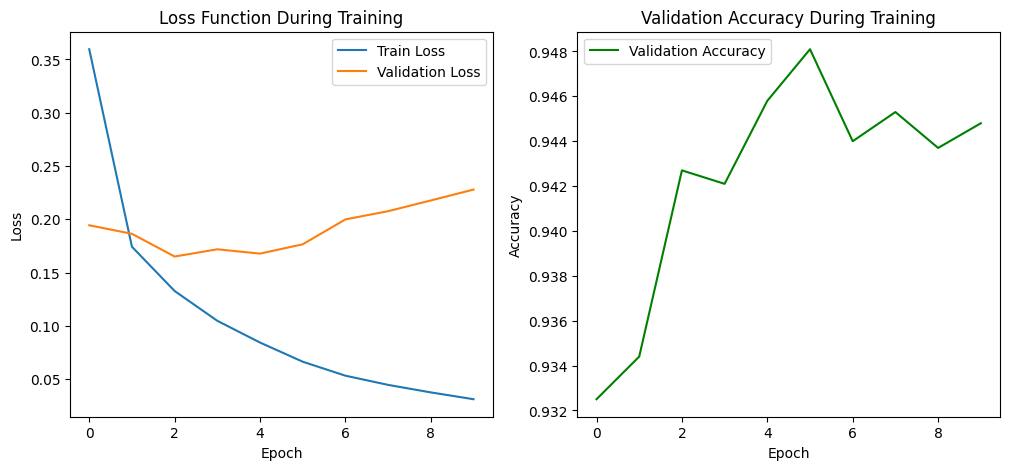

In [7]:
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 10

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(test_loader)
    val_losses.append(val_loss)
    val_acc = accuracy_score(all_labels, all_preds)
    val_accuracies.append(val_acc)

    print(f"✅ Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

# === Графики ===
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss Function During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_accuracies, label='Validation Accuracy', color='green')
plt.title('Validation Accuracy During Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

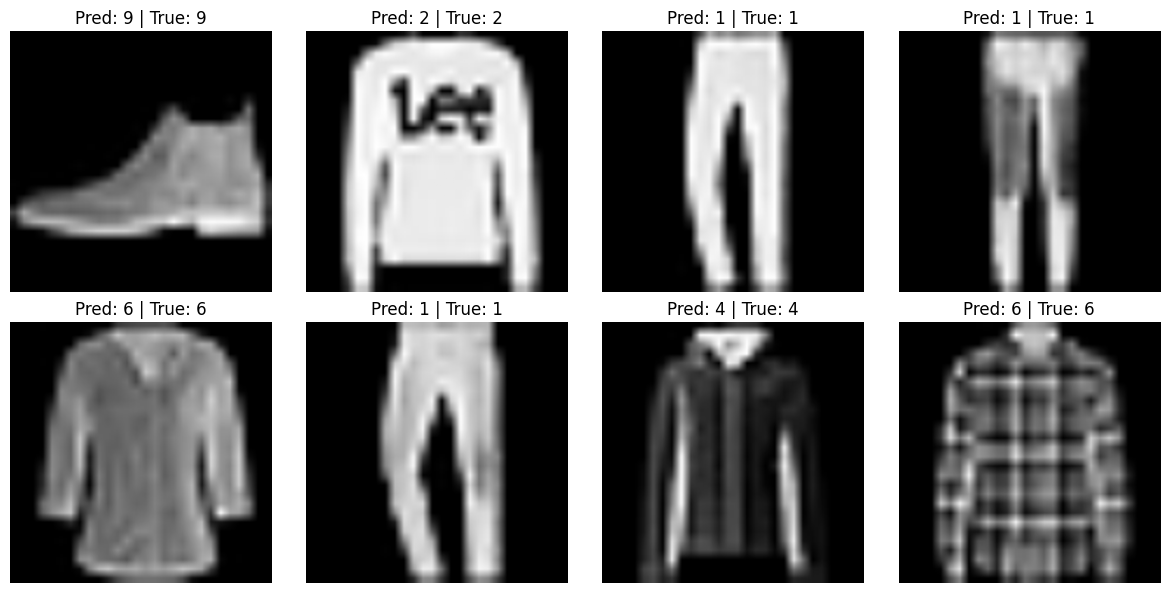

In [9]:
model.eval()
data_iter = iter(test_loader)
images, labels = next(data_iter)
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, preds = torch.max(outputs, 1)

# Покажем 8 изображений
fig, axes = plt.subplots(2, 4, figsize=(12,6))
axes = axes.flatten()
for i in range(8):
    img = images[i].cpu().permute(1,2,0).numpy()
    img = (img * 0.5 + 0.5).clip(0,1)  # обратное нормирование
    axes[i].imshow(img)
    axes[i].set_title(f"Pred: {preds[i].item()} | True: {labels[i].item()}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
precision_cls, recall_cls, f1_cls, _ = precision_recall_fscore_support(all_labels, all_preds, average=None)

print("\n=== Метрики (в среднем по всем классам) ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\n=== Метрики по каждому классу ===")
for i, (p, r, f) in enumerate(zip(precision_cls, recall_cls, f1_cls)):
    print(f"Класс {i}:  Precision={p:.4f}, Recall={r:.4f}, F1={f:.4f}")


=== Метрики (в среднем по всем классам) ===
Accuracy:  0.9469
Precision: 0.9471
Recall:    0.9469
F1-score:  0.9466

=== Метрики по каждому классу ===
Класс 0:  Precision=0.8696, Recall=0.9140, F1=0.8913
Класс 1:  Precision=0.9980, Recall=0.9900, F1=0.9940
Класс 2:  Precision=0.9325, Recall=0.9260, F1=0.9293
Класс 3:  Precision=0.9589, Recall=0.9340, F1=0.9463
Класс 4:  Precision=0.9045, Recall=0.9750, F1=0.9384
Класс 5:  Precision=0.9960, Recall=0.9850, F1=0.9904
Класс 6:  Precision=0.8749, Recall=0.7970, F1=0.8341
Класс 7:  Precision=0.9768, Recall=0.9700, F1=0.9734
Класс 8:  Precision=0.9940, Recall=0.9950, F1=0.9945
Класс 9:  Precision=0.9656, Recall=0.9830, F1=0.9742


**Неплохое качество выдала самая простая модель В0**